# TP2

Baptiste Wehry

Annotation: Some code during first 5 questions are given but aren't asked during the questions. I put them because they will be helpful later on for question 6 for the different indicators

# Question 1 : Checking the file format

I opened the files in a text editor first.

- cars.csv and film.csv use ';' as separator, and the second line contains the data types (STRING, INT, DOUBLE...) instead of real data. So I use skiprows=[1].
- They also have special characters, so I need an encoding.
- The Northwind files use `,' as separator and are fine as they are.

# Question 2: Reading the files

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [112]:
cars_df = pd.read_csv(r'C:\Users\Baptiste\Downloads\cars.csv', sep=";", encoding="ISO-8859-1", skiprows=[1])
films_df = pd.read_csv(r"C:\Users\Baptiste\Downloads\film.csv", sep=";", encoding="latin1", skiprows=[1])

orders_df = pd.read_csv(r"C:\Users\Baptiste\Downloads\Northwind\orders.csv", sep=",")
details_df = pd.read_csv(r"C:\Users\Baptiste\Downloads\Northwind\order-details.csv", sep=",")
products_df = pd.read_csv(r"C:\Users\Baptiste\Downloads\Northwind\products.csv", sep=",")
employees_df = pd.read_csv(r"C:\Users\Baptiste\Downloads\Northwind\employees.csv", sep=",")
customers_df = pd.read_csv(r"C:\Users\Baptiste\Downloads\Northwind\customer.csv", sep=",")
categories_df = pd.read_csv(r"C:\Users\Baptiste\Downloads\Northwind\categories.csv", sep=",")

In [113]:
print(cars_df.shape)
print(films_df.shape)
print(orders_df.shape)
print(details_df.shape)
print(products_df.shape)
print(employees_df.shape)
print(customers_df.shape)
print(categories_df.shape)

(406, 9)
(1659, 10)
(830, 14)
(2155, 5)
(77, 10)
(9, 18)
(91, 11)
(8, 4)


In [114]:
cars_df.head()

,Car,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model,Origin
0,Chevrolet Chevelle Malibu,18.0,8,307.0,130.0,3504.0,12.0,70,US
1,Buick Skylark 320,15.0,8,350.0,165.0,3693.0,11.5,70,US
2,Plymouth Satellite,18.0,8,318.0,150.0,3436.0,11.0,70,US
3,AMC Rebel SST,16.0,8,304.0,150.0,3433.0,12.0,70,US
4,Ford Torino,17.0,8,302.0,140.0,3449.0,10.5,70,US


In [115]:
films_df.head()

,Year,Length,Title,Subject,Actor,Actress,Director,Popularity,Awards,*Image
0,1990,111.0,Tie Me Up! Tie Me Down!,Comedy,"Banderas, Antonio","Abril, Victoria","Almodóvar, Pedro",68.0,No,NicholasCage.png
1,1991,113.0,High Heels,Comedy,"Bosé, Miguel","Abril, Victoria","Almodóvar, Pedro",68.0,No,NicholasCage.png
2,1983,104.0,"Dead Zone, The",Horror,"Walken, Christopher","Adams, Brooke","Cronenberg, David",79.0,No,NicholasCage.png
3,1979,122.0,Cuba,Action,"Connery, Sean","Adams, Brooke","Lester, Richard",6.0,No,seanConnery.png
4,1978,94.0,Days of Heaven,Drama,"Gere, Richard","Adams, Brooke","Malick, Terrence",14.0,No,NicholasCage.png


In [116]:
orders_df.head()

,order_id,customer_id,employee_id,order_date,required_date,shipped_date,ship_via,freight,ship_name,ship_address,ship_city,ship_region,ship_postal_code,ship_country
0,10248,VINET,5,1996-07-04,1996-08-01,1996-07-16,3,32.38,Vins et alcools Chevalier,59 rue de l'Abbaye,Reims,NaN,51100,France
1,10249,TOMSP,6,1996-07-05,1996-08-16,1996-07-10,1,11.61,Toms SpezialitÃ¤ten,Luisenstr. 48,MÃ¼nster,NaN,44087,Germany
2,10250,HANAR,4,1996-07-08,1996-08-05,1996-07-12,2,65.83,Hanari Carnes,"Rua do PaÃ§o, 67",Rio de Janeiro,RJ,05454-876,Brazil
3,10251,VICTE,3,1996-07-08,1996-08-05,1996-07-15,1,41.34,Victuailles en stock,"2, rue du Commerce",Lyon,NaN,69004,France
4,10252,SUPRD,4,1996-07-09,1996-08-06,1996-07-11,2,51.30,SuprÃªmes dÃ©lices,"Boulevard Tirou, 255",Charleroi,NaN,B-6000,Belgium


# Question 3 : Note on pre-processing

Here I found 3 problems:

- the type row in cars and film (already removed with skiprows)
- some zeros in cars that are actually missing values
- the column names are not the same between orders and order-details, so the merge does not work directly

I fix them in question 4.

# Question 4 : Pre-processing


For Cars

In [117]:
# To check missing values
print(cars_df.isnull().sum())

Car             0
MPG             0
Cylinders       0
Displacement    0
Horsepower      0
Weight          0
Acceleration    0
Model           0
Origin          0
dtype: int64


In [118]:
# There are no 'NaN' but there are zeros that make no sense
print((cars_df["MPG"] == 0).sum(), "zeros in MPG")
print((cars_df["Horsepower"] == 0).sum(), "zeros in Horsepower")

8 zeros in MPG
6 zeros in Horsepower


In [119]:
# a car cannot have 0 horsepower, so I replace the zeros by NaN
cars_df["MPG"] = cars_df["MPG"].replace(0, np.nan)
cars_df["Horsepower"] = cars_df["Horsepower"].replace(0, np.nan)

#Here were verify that it was replaced by checking the min, and we have that they are correctly replaced 
print(cars_df["MPG"].min())
print(cars_df["Horsepower"].min())

#I keep the rows because the other columns are still good, and pandas ignores NaN when it computes a mean.

9.0
46.0



Films

In [120]:
print(films_df.isnull().sum())

Year            0
Length         67
Title           0
Subject         2
Actor           8
Actress       378
Director      253
Popularity      6
Awards          0
*Image          0
dtype: int64


There are a lot of missing values in Actress and Director. 

Attention: I do not delete them because the missing directors are exactly what I study in indicator 2 later on in the TP for question 6.

I just add two columns that will be useful after.

In [121]:
films_df["AwardWon"] = films_df["Awards"] == "Yes"
films_df["Decade"] = (films_df["Year"] // 10) * 10
films_df.head(3)

,Year,Length,Title,Subject,Actor,Actress,Director,Popularity,Awards,*Image,AwardWon,Decade
0,1990,111.0,Tie Me Up! Tie Me Down!,Comedy,"Banderas, Antonio","Abril, Victoria","Almodóvar, Pedro",68.0,No,NicholasCage.png,False,1990
1,1991,113.0,High Heels,Comedy,"Bosé, Miguel","Abril, Victoria","Almodóvar, Pedro",68.0,No,NicholasCage.png,False,1990
2,1983,104.0,"Dead Zone, The",Horror,"Walken, Christopher","Adams, Brooke","Cronenberg, David",79.0,No,NicholasCage.png,False,1980


Northwind

Here the problem is the column names. In 'orders' the key is called 'order_id' but in 'order-details' it is called 'orderID'. So I rename them so that we can work on them later

In [122]:
print(orders_df.columns.tolist())
print(details_df.columns.tolist())

#Exemple of the problem right here, we have the 2 keys that don't correspond in their name while in the diagram they are foreign/primary
#keys so linked to each others

['order_id', 'customer_id', 'employee_id', 'order_date', 'required_date', 'shipped_date', 'ship_via', 'freight', 'ship_name', 'ship_address', 'ship_city', 'ship_region', 'ship_postal_code', 'ship_country']
['orderID', 'productID', 'unitPrice', 'quantity', 'discount']


In [123]:
orders_df = orders_df.rename(columns={"order_id": "orderID",
                                      "customer_id": "customerID",
                                      "employee_id": "employeeID",
                                      "order_date": "orderDate"})

orders_df["orderDate"] = pd.to_datetime(orders_df["orderDate"])
orders_df.head(3)

,orderID,customerID,employeeID,orderDate,required_date,shipped_date,ship_via,freight,ship_name,ship_address,ship_city,ship_region,ship_postal_code,ship_country
0,10248,VINET,5,1996-07-04,1996-08-01,1996-07-16,3,32.38,Vins et alcools Chevalier,59 rue de l'Abbaye,Reims,NaN,51100,France
1,10249,TOMSP,6,1996-07-05,1996-08-16,1996-07-10,1,11.61,Toms SpezialitÃ¤ten,Luisenstr. 48,MÃ¼nster,NaN,44087,Germany
2,10250,HANAR,4,1996-07-08,1996-08-05,1996-07-12,2,65.83,Hanari Carnes,"Rua do PaÃ§o, 67",Rio de Janeiro,RJ,05454-876,Brazil


In [124]:
# in customers the missing values are written "NULL"
customers_df = customers_df.replace("NULL", np.nan)
customers_df.head(3)

,customerID,companyName,contactName,contactTitle,address,city,region,postalCode,country,phone,fax
0,ALFKI,Alfreds Futterkiste,Maria Anders,Sales Representative,Obere Str. 57,Berlin,NaN,12209,Germany,030-0074321,030-0076545
1,ANATR,Ana Trujillo Emparedados y helados,Ana Trujillo,Owner,Avda. de la Constitución 2222,México D.F.,NaN,05021,Mexico,(5) 555-4729,(5) 555-3745
2,ANTON,Antonio Moreno Taquería,Antonio Moreno,Owner,Mataderos 2312,México D.F.,NaN,05023,Mexico,(5) 555-3932,NaN


I also create the revenue column, because the price and the quantity are in two different columns and there is a discount.

revenue = unitPrice * quantity * (1 - discount)

In [125]:
details_df["revenue"] = details_df["unitPrice"] * details_df["quantity"] * (1 - details_df["discount"])
details_df.head()

,orderID,productID,unitPrice,quantity,discount,revenue
0,10248,11,14.0,12,0.0,168.0
1,10248,42,9.8,10,0.0,98.0
2,10248,72,34.8,5,0.0,174.0
3,10249,14,18.6,9,0.0,167.4
4,10249,51,42.4,40,0.0,1696.0


# Question 5 : Describing the datasets

In [126]:
cars_df.dtypes

Car                 str
MPG             float64
Cylinders         int64
Displacement    float64
Horsepower      float64
Weight          float64
Acceleration    float64
Model             int64
Origin              str
dtype: object

In [127]:
cars_df.describe()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model
count,398.000000,406.000000,406.000000,400.000000,406.000000,406.000000,406.000000
mean,23.514573,5.475369,194.779557,105.082500,2979.413793,15.519704,75.921182
std,7.815984,1.712160,104.922458,38.768779,847.004328,2.803359,3.748737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,105.000000,75.750000,2226.500000,13.700000,73.000000
50%,23.000000,4.000000,151.000000,95.000000,2822.500000,15.500000,76.000000
75%,29.000000,8.000000,302.000000,130.000000,3618.250000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [128]:
films_df.dtypes

Year            int64
Length        float64
Title             str
Subject           str
Actor             str
Actress           str
Director          str
Popularity    float64
Awards            str
*Image            str
AwardWon         bool
Decade          int64
dtype: object

In [129]:
films_df.describe()

,Year,Length,Popularity,Decade
count,1659.000000,1592.000000,1653.000000,1659.000000
mean,1975.802893,105.179648,43.110103,1971.374322
std,17.057848,30.629501,26.747406,17.549973
min,1920.000000,5.000000,0.000000,1920.000000
25%,1967.000000,90.000000,19.000000,1960.000000
50%,1983.000000,102.000000,43.000000,1980.000000
75%,1989.000000,116.000000,67.000000,1980.000000
max,1997.000000,450.000000,88.000000,1990.000000


In [130]:
details_df.dtypes

orderID        int64
productID      int64
unitPrice    float64
quantity       int64
discount     float64
revenue      float64
dtype: object

In [131]:
details_df.describe()

,orderID,productID,unitPrice,quantity,discount,revenue
count,2155.000000,2155.000000,2155.000000,2155.000000,2155.000000,2155.000000
mean,10659.375870,40.793039,26.218520,23.812993,0.056167,587.374960
std,241.378032,22.159019,29.827418,19.022047,0.083450,969.224235
min,10248.000000,1.000000,2.000000,1.000000,0.000000,4.800000
25%,10451.000000,22.000000,12.000000,10.000000,0.000000,147.000000
50%,10657.000000,41.000000,18.400000,20.000000,0.000000,337.750000
75%,10862.500000,60.000000,32.000000,30.000000,0.100000,656.000000
max,11077.000000,77.000000,263.500000,130.000000,0.250000,15810.000000


In [132]:
orders_df.dtypes

orderID                      int64
customerID                     str
employeeID                   int64
orderDate           datetime64[us]
required_date                  str
shipped_date                   str
ship_via                     int64
freight                    float64
ship_name                      str
ship_address                   str
ship_city                      str
ship_region                    str
ship_postal_code               str
ship_country                   str
dtype: object

In [133]:
orders_df.describe()

,orderID,employeeID,orderDate,ship_via,freight
count,830.000000,830.000000,830,830.000000,830.000000
mean,10662.500000,4.403614,1997-08-08 08:12:43.373494,2.007229,78.244205
min,10248.000000,1.000000,1996-07-04 00:00:00,1.000000,0.020000
25%,10455.250000,2.000000,1997-02-24 06:00:00,1.000000,13.380000
50%,10662.500000,4.000000,1997-09-09 12:00:00,2.000000,41.360000
75%,10869.750000,7.000000,1998-02-04 00:00:00,3.000000,91.430000
max,11077.000000,9.000000,1998-05-06 00:00:00,3.000000,1007.640000
std,239.744656,2.499648,NaN,0.779685,116.779294


In [134]:
products_df.describe()

,productID,supplierID,categoryID,unitPrice,unitsInStock,unitsOnOrder,reorderLevel,discontinued
count,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000
mean,39.000000,13.649351,4.116883,28.866364,40.506494,10.129870,12.467532,0.103896
std,22.371857,8.220267,2.395028,33.815111,36.147222,23.141072,10.931105,0.307127
min,1.000000,1.000000,1.000000,2.500000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,7.000000,2.000000,13.250000,15.000000,0.000000,0.000000,0.000000
50%,39.000000,13.000000,4.000000,19.500000,26.000000,0.000000,10.000000,0.000000
75%,58.000000,20.000000,6.000000,33.250000,61.000000,0.000000,25.000000,0.000000
max,77.000000,29.000000,8.000000,263.500000,125.000000,100.000000,30.000000,1.000000


In [135]:
# Products
products_df.dtypes

productID            int64
productName            str
supplierID           int64
categoryID           int64
quantityPerUnit        str
unitPrice          float64
unitsInStock         int64
unitsOnOrder         int64
reorderLevel         int64
discontinued         int64
dtype: object

In [136]:
# Employees
employees_df.dtypes

employeeID           int64
lastName               str
firstName              str
title                  str
titleOfCourtesy        str
birthDate              str
hireDate               str
address                str
city                   str
region                 str
postalCode             str
country                str
homePhone              str
extension            int64
photo                  str
notes                  str
reportsTo          float64
photoPath              str
dtype: object

In [137]:
employees_df.describe()

,employeeID,extension,reportsTo
count,9.000000,9.000000,8.000000
mean,5.000000,2733.000000,3.125000
std,2.738613,1958.430366,1.552648
min,1.000000,428.000000,2.000000
25%,3.000000,465.000000,2.000000
50%,5.000000,3355.000000,2.000000
75%,7.000000,3457.000000,5.000000
max,9.000000,5467.000000,5.000000


In [138]:
# Customers
customers_df.dtypes

customerID      str
companyName     str
contactName     str
contactTitle    str
address         str
city            str
region          str
postalCode      str
country         str
phone           str
fax             str
dtype: object

In [139]:
customers_df.describe()

,customerID,companyName,contactName,contactTitle,address,city,region,postalCode,country,phone,fax
count,91,91,91,91,91,91,31,90,91,91,69
unique,91,91,91,12,91,70,18,86,21,91,69
top,ALFKI,Alfreds Futterkiste,Maria Anders,Sales Representative,Obere Str. 57,London,SP,1010,USA,030-0074321,030-0076545
freq,1,1,1,17,1,6,6,3,13,1,1


In [140]:
categories_df.dtypes

categoryID      int64
categoryName      str
description       str
picture           str
dtype: object

In [141]:
categories_df.describe()

,categoryID
count,8.00000
mean,4.50000
std,2.44949
min,1.00000
25%,2.75000
50%,4.50000
75%,6.25000
max,8.00000


The datasets looks correct now. The minimum of MPG is 9 and not 0 anymore, so the cleaning worked.

# Question 6: Indicators

3 indicators for cars, 3 for films and 3 for Northwind (with at least 2 dataframes each time).

 6.1 Cars

# Indicator 1 : The 10 most powerful cars

This shows the best cars of the fleet, with their consumption. It is useful for a rental company to know which cars are in the premium category.

In [142]:
top10 = cars_df.sort_values("Horsepower", ascending=False).head(10)
top10[["Car", "Horsepower", "Cylinders", "MPG", "Origin"]]

,Car,Horsepower,Cylinders,MPG,Origin
123,Pontiac Grand Prix,230.0,8,16.0,US
102,Buick Electra 225 Custom,225.0,8,12.0,US
19,Buick Estate Wagon (sw),225.0,8,14.0,US
8,Pontiac Catalina,225.0,8,14.0,US
6,Chevrolet Impala,220.0,8,14.0,US
31,Ford F250,215.0,8,10.0,US
101,Chrysler New Yorker Brougham,215.0,8,13.0,US
7,Plymouth Fury iii,215.0,8,14.0,US
33,Dodge D200,210.0,8,11.0,US
74,Mercury Marquis,208.0,8,11.0,US


The 10 most powerful cars are all American and all have 8 cylinders. They consume a lot: between 10 and 16 MPG while the average of the fleet is 23. So more power means more fuel.

# Indicator 2 : Average characteristics by origin

This gives the profile of the cars for each region (US, Europe, Japan). It helps to know where the company buys its cars.

In [143]:
by_origin = cars_df.groupby("Origin")[["MPG", "Horsepower", "Weight", "Cylinders"]].mean()
by_origin = by_origin.round(2)
by_origin

,MPG,Horsepower,Weight,Cylinders
Origin,,,,
Europe,27.89,81.00,2431.49,4.15
Japan,30.45,79.84,2221.23,4.10
US,20.08,119.90,3372.70,6.28


In [144]:
print(cars_df["Origin"].value_counts())

Origin
US        254
Japan      79
Europe     73
Name: count, dtype: int64


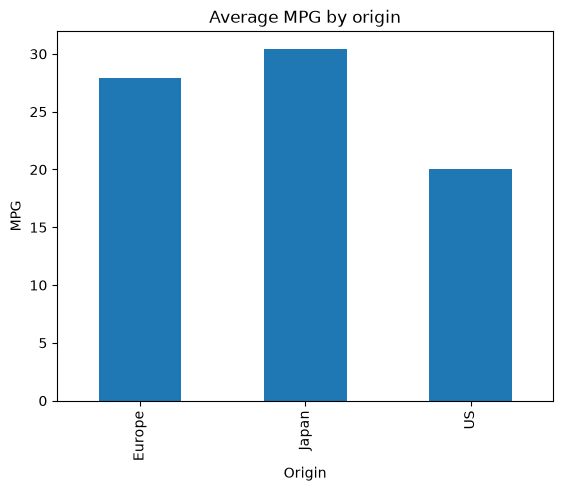

In [145]:
by_origin["MPG"].plot(kind="bar")
plt.title("Average MPG by origin")
plt.ylabel("MPG")
plt.show()

Japanese cars consume the least (30.45 MPG) and American cars the most (20.08 MPG). But American cars are more powerful (119.9 hp against 79.8) and heavier (3373 against 2221). There are 254 American cars out of 406, so more than half of the fleet.

# Indicator 3 : Average MPG by model year

This shows if the cars become more economic with the years.

In [146]:
by_year = cars_df.groupby("Model")[["MPG", "Horsepower"]].mean().round(2)
by_year

,MPG,Horsepower
Model,,
70,17.69,148.86
71,21.25,104.93
72,18.71,120.18
73,17.10,130.48
74,22.70,94.23
75,20.27,101.07
76,21.57,101.12
77,23.38,105.07
78,24.06,99.69


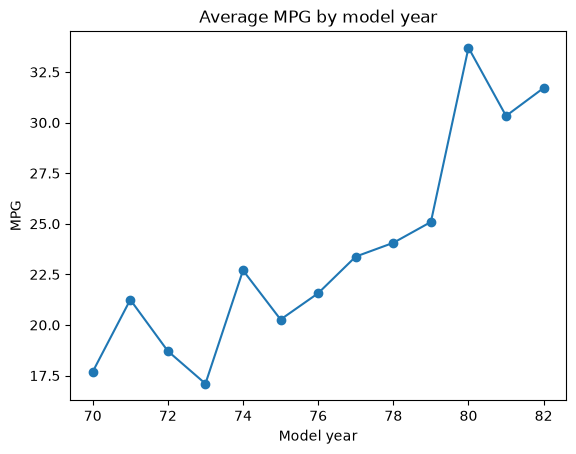

In [147]:
by_year["MPG"].plot(marker="o")
plt.title("Average MPG by model year")
plt.xlabel("Model year")
plt.ylabel("MPG")
plt.show()

The consumption gets much better: 17.69 MPG in 1970 and 31.71 MPG in 1982. At the same time the power goes down (148.9 to 81.5 hp). There is a big jump between 1979 and 1980 (25.09 to 33.70), probably because of the oil crisis.

## 6.2 Films

# Indicator 1 : Number of films with the Nicolas Cage image

This is the example given in the subject. It counts how many films use the same image.

In [148]:
nb_cage = (films_df["*Image"] == "NicholasCage.png").sum()
print("Number of films with NicholasCage.png :", nb_cage)
print("Total number of films :", len(films_df))
print("Percentage :", round(nb_cage / len(films_df) * 100, 1), "%")

Number of films with NicholasCage.png : 1151
Total number of films : 1659
Percentage : 69.4 %


In [149]:
films_df["*Image"].value_counts().head(8)

*Image
NicholasCage.png       1151
johnWayne.png            80
clintEastwood.png        33
alfredHitchcock.png      30
seanConnery.png          28
Bergman.png              28
paulNewman.png           28
ingridBergman.png        27
Name: count, dtype: int64

1151 films out of 1659 use this image, so 69.4% of the catalogue. It is clearly a default image and not a real cover. The second image only appears 80 times.

# Indicator 2 : Films without a director

This counts the films where the director is missing, and I look at it by decade to see if it is always the same.

In [150]:
print("Films without director :", films_df["Director"].isnull().sum())
print("Percentage :", round(films_df["Director"].isnull().mean() * 100, 1), "%")

Films without director : 253
Percentage : 15.3 %


In [151]:
no_dir = films_df.groupby("Decade")["Director"].apply(lambda x: x.isnull().sum())
total = films_df.groupby("Decade")["Title"].count()

result = pd.DataFrame({"nb_films": total, "no_director": no_dir})
result["percent"] = (result["no_director"] / result["nb_films"] * 100).round(1)
result

,nb_films,no_director,percent
Decade,,,
1920,23,0,0.0
1930,69,13,18.8
1940,90,2,2.2
1950,127,13,10.2
1960,154,8,5.2
1970,244,17,7.0
1980,607,63,10.4
1990,345,137,39.7


253 films have no director (15.3%). But it is not the same for all decades: it is around 2 to 10% before 1980, and it goes up to 39.7% in the 1990s. So it is not an old films problem, it is the recent films that are badly filled.

# Indicator 3 : Number of awards by genre

This shows which genres win the most awards.

In [152]:
by_subject = films_df.groupby("Subject").agg({"Title": "count", "AwardWon": "sum", "Popularity": "mean"})
by_subject.columns = ["nb_films", "nb_awards", "avg_popularity"]
by_subject["award_rate"] = (by_subject["nb_awards"] / by_subject["nb_films"] * 100).round(1)
by_subject = by_subject[by_subject["nb_films"] >= 20]
by_subject.sort_values("award_rate", ascending=False).round(1)

,nb_films,nb_awards,avg_popularity,award_rate
Subject,,,,
Drama,655,113,44.2,17.3
Science Fiction,38,4,42.5,10.5
Music,43,4,46.1,9.3
Comedy,385,31,42.8,8.1
War,34,2,41.3,5.9
Horror,57,2,46.5,3.5
Western,119,4,44.3,3.4
Mystery,107,2,40.7,1.9
Action,205,0,39.0,0.0


Drama is by far the best genre for awards (17.3%) and it also has the most awarded films (113). Action has 0 award for 205 films. The average of the whole catalogue is 9.8%.

## 6.3 Northwind

For this dataset each indicator uses at least 2 dataframes.

# Indicator 1 :Top 10 customers by revenue

Dataframes used: order-details + orders + customers

This shows which customers bring the most money to the company.

In [153]:

cust = details_df.merge(orders_df[["orderID", "customerID"]], on="orderID")
cust = cust.merge(customers_df[["customerID", "companyName", "country"]], on="customerID")
cust.head(3)

,orderID,productID,unitPrice,quantity,discount,revenue,customerID,companyName,country
0,10248,11,14.0,12,0.0,168.0,VINET,Vins et alcools Chevalier,France
1,10248,42,9.8,10,0.0,98.0,VINET,Vins et alcools Chevalier,France
2,10248,72,34.8,5,0.0,174.0,VINET,Vins et alcools Chevalier,France


In [154]:
top_cust = cust.groupby(["companyName", "country"]).agg({"revenue": "sum", "orderID": "nunique"})
top_cust.columns = ["revenue", "nb_orders"]
top_cust["avg_order"] = (top_cust["revenue"] / top_cust["nb_orders"]).round(2)
top_cust = top_cust.sort_values("revenue", ascending=False).round(2)
top_cust.head(10)

,,revenue,nb_orders,avg_order
companyName,country,,,
QUICK-Stop,Germany,110277.30,28,3938.48
Ernst Handel,Austria,104874.98,30,3495.83
Save-a-lot Markets,USA,104361.95,31,3366.51
Rattlesnake Canyon Grocery,USA,51097.80,18,2838.77
Hungry Owl All-Night Grocers,Ireland,49979.90,19,2630.52
Hanari Carnes,Brazil,32841.37,14,2345.81
Königlich Essen,Germany,30908.38,14,2207.74
Folk och fä HB,Sweden,29567.56,19,1556.19
Mère Paillarde,Canada,28872.19,13,2220.94


In [155]:
total = top_cust["revenue"].sum()
print("Total revenue :", round(total, 2))
print("Part of the top 10 :", round(top_cust.head(10)["revenue"].sum() / total * 100, 1), "%")

Total revenue : 1265793.01
Part of the top 10 : 45.0 %


The total revenue is 1 265 793. The first customer is QUICK-Stop with 110 277, then Ernst Handel and Save-a-lot Markets around 104 000.

The top 10 customers represent 45% of the revenue, so the company depends a lot on a few customers.

### Indicator 2 - Revenue by employee

**Dataframes used: order-details + orders + employees**

This shows which salesperson sells the most.

In [156]:
emp = details_df.merge(orders_df[["orderID", "employeeID"]], on="orderID")
emp = emp.merge(employees_df[["employeeID", "firstName", "lastName", "title"]], on="employeeID")
emp["name"] = emp["firstName"] + " " + emp["lastName"]
emp.head(3)

,orderID,productID,unitPrice,quantity,discount,revenue,employeeID,firstName,lastName,title,name
0,10248,11,14.0,12,0.0,168.0,5,Steven,Buchanan,Sales Manager,Steven Buchanan
1,10248,42,9.8,10,0.0,98.0,5,Steven,Buchanan,Sales Manager,Steven Buchanan
2,10248,72,34.8,5,0.0,174.0,5,Steven,Buchanan,Sales Manager,Steven Buchanan


In [157]:
by_emp = emp.groupby(["name", "title"]).agg({"revenue": "sum", "orderID": "nunique"})
by_emp.columns = ["revenue", "nb_orders"]
by_emp["avg_order"] = (by_emp["revenue"] / by_emp["nb_orders"]).round(2)
by_emp = by_emp.sort_values("revenue", ascending=False).round(2)
by_emp

,,revenue,nb_orders,avg_order
name,title,,,
Margaret Peacock,Sales Representative,232890.85,156,1492.89
Janet Leverling,Sales Representative,202812.84,127,1596.95
Nancy Davolio,Sales Representative,192107.60,123,1561.85
Andrew Fuller,"Vice President, Sales",166537.76,96,1734.77
Laura Callahan,Inside Sales Coordinator,126862.28,104,1219.83
Robert King,Sales Representative,124568.24,72,1730.11
Anne Dodsworth,Sales Representative,77308.07,43,1797.86
Michael Suyama,Sales Representative,73913.13,67,1103.18
Steven Buchanan,Sales Manager,68792.28,42,1637.91


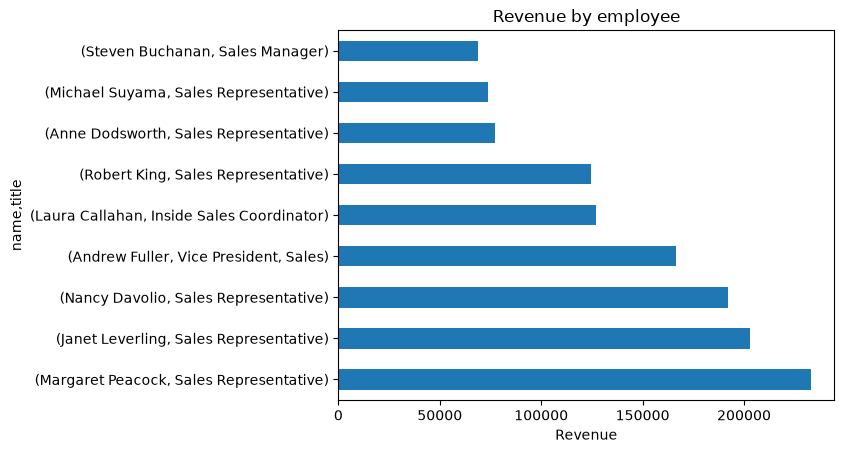

In [158]:
by_emp["revenue"].plot(kind="barh")
plt.title("Revenue by employee")
plt.xlabel("Revenue")
plt.show()

Margaret Peacock is the first with 232 890, and Steven Buchanan the last with 68 792, so more than 3 times less.

But if we look at the average order it is different: Anne Dodsworth has the best average (1797) with only 43 orders, while Margaret Peacock has 1492 with 156 orders. So Peacock sells a lot of small orders and Dodsworth few big ones.

# Indicator 3 : Revenue by product category

Dataframes used: order-details + products + categories

This shows which type of product sells the best.

In [159]:
cat = details_df.merge(products_df[["productID", "productName", "categoryID"]], on="productID")
cat = cat.merge(categories_df[["categoryID", "categoryName"]], on="categoryID")
cat.head(3)

,orderID,productID,unitPrice,quantity,discount,revenue,productName,categoryID,categoryName
0,10248,11,14.0,12,0.0,168.0,Queso Cabrales,4,Dairy Products
1,10248,42,9.8,10,0.0,98.0,Singaporean Hokkien Fried Mee,5,Grains/Cereals
2,10248,72,34.8,5,0.0,174.0,Mozzarella di Giovanni,4,Dairy Products


In [160]:
by_cat = cat.groupby("categoryName").agg({"revenue": "sum", "quantity": "sum"})
by_cat.columns = ["revenue", "units_sold"]
by_cat["percent"] = (by_cat["revenue"] / by_cat["revenue"].sum() * 100).round(2)
by_cat = by_cat.sort_values("revenue", ascending=False).round(2)
by_cat

,revenue,units_sold,percent
categoryName,,,
Beverages,267868.18,9532,21.16
Dairy Products,234507.28,9149,18.53
Confections,167357.22,7906,13.22
Meat/Poultry,163022.36,4199,12.88
Seafood,131261.74,7681,10.37
Condiments,106047.08,5298,8.38
Produce,99984.58,2990,7.90
Grains/Cereals,95744.59,4562,7.56


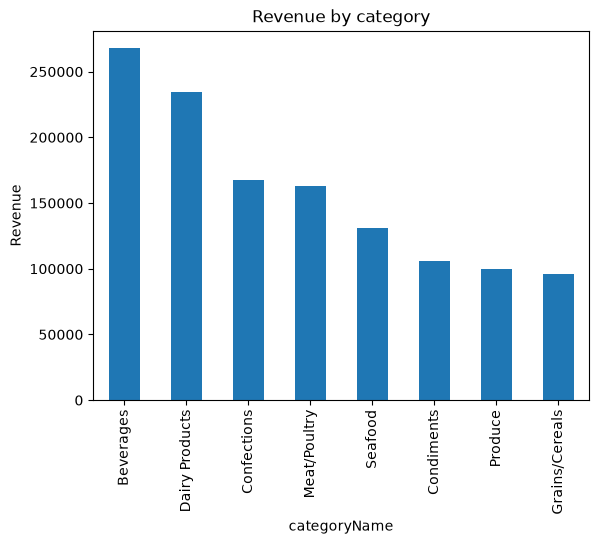

In [161]:
by_cat["revenue"].plot(kind="bar")
plt.title("Revenue by category")
plt.ylabel("Revenue")
plt.show()

Beverages is the first category with 267 868 (21.2%) and Dairy Products the second with 234 507 (18.5%).

Meat/Poultry is interesting: it is 4th for the revenue (163 022) but it only sold 4199 units, much less than the others. So the products are more expensive.

In [162]:

best = cat.groupby(["categoryName", "productName"])["revenue"].sum().reset_index()
best = best.sort_values("revenue", ascending=False).head(8)
best.round(2)

,categoryName,productName,revenue
3,Beverages,Côte de Blaye,141396.73
58,Meat/Poultry,Thüringer Rostbratwurst,80368.67
46,Dairy Products,Raclette Courdavault,71155.70
33,Confections,Tarte au sucre,47234.97
37,Dairy Products,Camembert Pierrot,46825.48
48,Grains/Cereals,Gnocchi di nonna Alice,42593.06
61,Produce,Manjimup Dried Apples,41819.65
54,Meat/Poultry,Alice Mutton,32698.38


Cote de Blaye alone makes 141 396, which is more than half of the Beverages category and 11% of the total revenue of the company. It is a very big dependency on one single product.